### Importing The Libraries

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [84]:
Heart_CSV = pd.read_csv("disease_prediction.csv")
Heart_CSV.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [85]:
Heart_CSV.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   str    
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   str    
 10  alcohol_consumption  1000 non-null   str    
 11  physical_activity    1000 non-null   str    
 12  family_history       1000 non-null   str    
 13  disease              1000 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB


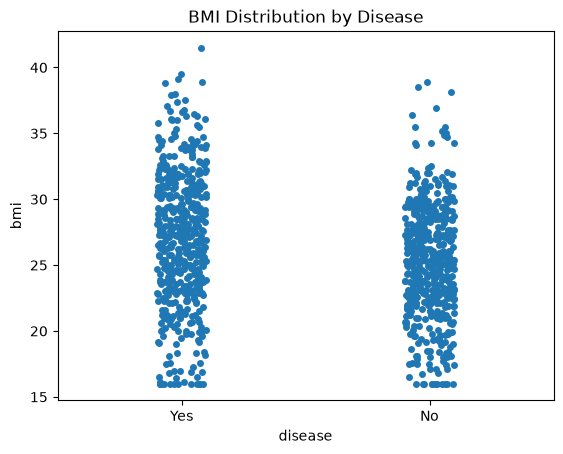

In [86]:
sns.stripplot(
    x='disease',
    y='bmi',
    data=Heart_CSV,
    jitter=True
)

plt.title("BMI Distribution by Disease")
plt.show()

### Encode categorical variables

### `LabelEncoder` converts text (categorical values) into numbers because machine learning algorithms like Logistic Regression work with numerical data, not strings.

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

Heart_CSV['gender'] = le.fit_transform(Heart_CSV['gender'])
Heart_CSV['smoking'] = le.fit_transform(Heart_CSV['smoking'])
Heart_CSV['alcohol_consumption'] = le.fit_transform(Heart_CSV['alcohol_consumption'])
Heart_CSV['physical_activity'] = le.fit_transform(Heart_CSV['physical_activity'])
Heart_CSV['family_history'] = le.fit_transform(Heart_CSV['family_history'])
Heart_CSV['disease'] = le.fit_transform(Heart_CSV['disease'])

In [88]:
Heart_CSV.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,1,101,235,152,79,28.5,73,0,1,1,1,1
1,2,31,1,124,191,134,77,33.9,71,0,1,1,1,1
2,3,45,1,57,141,114,71,27.2,79,1,1,1,0,0
3,4,75,0,69,268,120,82,21.5,61,1,1,2,0,1
4,5,53,1,107,163,131,75,23.3,73,1,0,1,1,1


### *Select features* - in `X`-`Input` takes all coloumn except `patient_id` bcz no use and `disease` bcz it is `y`-`Output` value which we predict

In [89]:
X = Heart_CSV.drop(columns=['patient_id', 'disease'])
y = Heart_CSV['disease']

### Split the data
### 20% for Test & 80% for Train - `test_size`
### `random_state=42` - This controls the random splitting.

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Standardize features

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train Logistic Regression

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.77
[[85 20]
 [26 69]]
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       105
           1       0.78      0.73      0.75        95

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



------

## When We use `One-Hot Encoding` insteed `LabelEncoding`

In [94]:
'''
Heart_CSV = pd.get_dummies(
    Heart_CSV,
    columns=[
        'gender',
        'smoking',
        'disease',
        'alcohol_consumption',
        'physical_activity',
        'family_history'
    ],
    drop_first=True,
    dtype=int
)


X = Heart_CSV.drop(columns=['patient_id', 'disease_Yes'])
y = Heart_CSV['disease_Yes']
'''


"\nHeart_CSV = pd.get_dummies(\n    Heart_CSV,\n    columns=[\n        'gender',\n        'smoking',\n        'disease',\n        'alcohol_consumption',\n        'physical_activity',\n        'family_history'\n    ],\n    drop_first=True,\n    dtype=int\n)\n\n\nX = Heart_CSV.drop(columns=['patient_id', 'disease_Yes'])\ny = Heart_CSV['disease_Yes']\n"

## Result

``` 
Accuracy: 0.86
[[94 11]
 [17 78]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       105
           1       0.88      0.82      0.85        95

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200
```